In [23]:
import random
import pandas as pd
import numpy as np

RANDOM_STATE = 123
random.seed(RANDOM_STATE)

N = 20
df_name = "AAPL_5min"

df = pd.read_csv(f'../datasets/{df_name}_marked.csv')

TRAIN_SIZE = int(0.9 * df.shape[0])
df_train, df_test = df[:TRAIN_SIZE], df[TRAIN_SIZE:]

In [24]:
def build_min_vectors_by_price(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_min'] or take_all:
            cur_vec = []
            for j in range(i - 1, i - N, -1):
                cur_vec.append((df.iloc[j]['open'] - df.iloc[i]['open']) / df.iloc[i]['open'])
            vectors.append(cur_vec)
    return np.array(vectors)

def build_max_vectors_by_price(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_max'] or take_all:
            cur_vec = []
            for j in range(i - 1, i - N, -1):
                cur_vec.append((df.iloc[j]['open'] - df.iloc[i]['open']) / df.iloc[i]['open'])
            vectors.append(cur_vec)
    return np.array(vectors)

X_train_min = build_min_vectors_by_price(df_train, N)
X_train_max = build_max_vectors_by_price(df_train, N)
print(X_train_min.shape, X_train_max.shape)

(91, 19) (105, 19)


***Сначала случай минимумов***

**Строим векторы отношений цен для трейна**

In [25]:
X_train_min[0]

array([ 0.00310552,  0.00472298,  0.00726779,  0.01067528,  0.00951066,
        0.00621105,  0.00539369,  0.00189782, -0.00015096,  0.00131549,
        0.00308396,  0.00235071,  0.00040976, -0.00067761, -0.00040976,
       -0.00041023, -0.00470142, -0.00329962, -0.00593069])

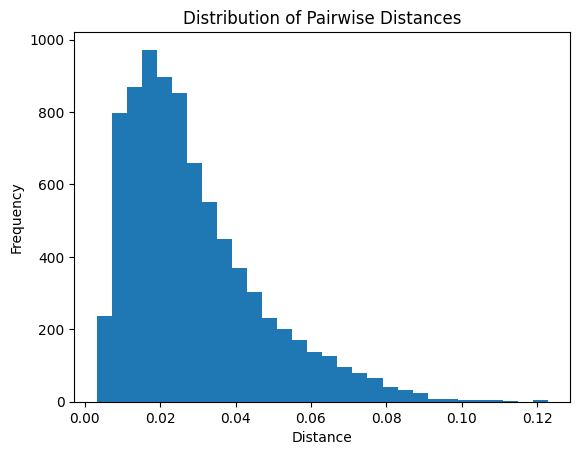

In [26]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_min)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [27]:
from sklearn.cluster import DBSCAN, KMeans

EPS = 0.01
clustering_dbscan = DBSCAN(eps=EPS, min_samples=5).fit(X_train_min)
clustering_dbscan.labels_

array([-1,  0,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1,  0,
        0,  0,  0,  0, -1,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0, -1,  0, -1,  0,  0,  0,  0,  0,  0,
        0,  0, -1,  0,  0,  0,  0,  0, -1,  0,  0, -1,  0,  0,  0,  0, -1,
       -1,  0, -1,  0,  0, -1,  0,  0,  0,  0,  0,  0,  0, -1,  0,  0, -1,
       -1, -1, -1, -1, -1, -1])

In [28]:
noise = np.where(clustering_dbscan.labels_ == -1)[0]
noise

array([ 0,  4, 15, 21, 27, 29, 42, 44, 53, 59, 62, 67, 68, 70, 73, 81, 84,
       85, 86, 87, 88, 89, 90])

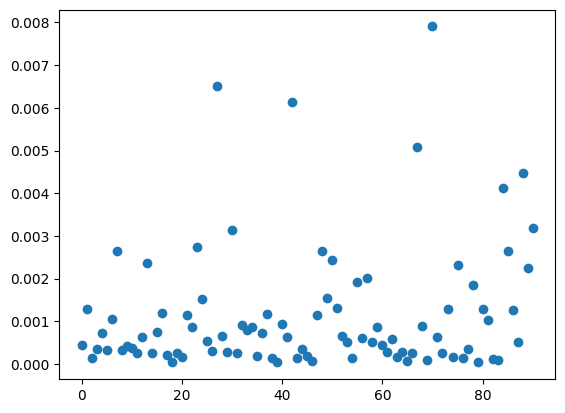

In [29]:
squared = np.diagonal(X_train_min @ X_train_min.T)
plt.scatter([i for i in range(squared.shape[0])], squared)
plt.show()

In [30]:
squared[noise]

array([0.00044637, 0.00072251, 0.00075944, 0.00115216, 0.0065016 ,
       0.00027029, 0.00612937, 0.0003558 , 0.0005133 , 0.00085574,
       0.00057739, 0.00507722, 0.00089186, 0.00790508, 0.00129026,
       0.00103861, 0.00412443, 0.00264827, 0.0012705 , 0.0005188 ,
       0.00447616, 0.00224511, 0.0031854 ])

In [31]:
clustering_kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit(X_train_min)
clustering_kmeans.labels_

array([0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1], dtype=int32)

In [32]:
X_test = build_min_vectors_by_price(df_test, N, take_all=True)

**Проверяем DBSCAN метрики на тесте**

In [33]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score


def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering_dbscan.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering_dbscan.labels_[clustering_dbscan.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_min, X_test[i - N], EPS)
    y_pred.append(prediction == -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.4265, Recall: 0.6667, Precision: 0.0211, F1 Score: 0.0410, ROC_AUC: 0.5444


**Проверяем Kmeans метрики на тесте**

In [34]:
def predict_kmeans(v, threshold=None):
    label = clustering_kmeans.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering_kmeans.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_min'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test[i - N], threshold=EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.8980, Recall: 0.1667, Precision: 0.0341, F1 Score: 0.0566, ROC_AUC: 0.5392


***Теперь аналогично для максимумов***

In [35]:
X_train_max[0]

array([-0.00036948, -0.00013041, -0.00115192, -0.00227211, -0.00547711,
       -0.00686807, -0.00617257, -0.00579261, -0.00643334, -0.00634645,
       -0.00473806, -0.00469463, -0.00560752, -0.00842599, -0.01066985,
       -0.00945447, -0.00755053, -0.0114975 , -0.01169311])

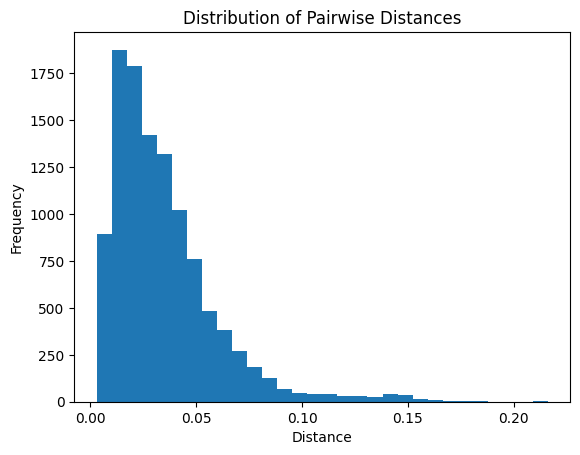

In [36]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train_max)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=30)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [37]:
from sklearn.cluster import DBSCAN, KMeans

EPS = 0.01
clustering_dbscan = DBSCAN(eps=EPS, min_samples=5).fit(X_train_max)
clustering_dbscan.labels_

array([ 0, -1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  0,  0, -1, -1,  0, -1,
        0,  0,  0,  0, -1, -1,  0, -1, -1,  0,  0, -1,  0,  0,  0,  0,  0,
       -1,  0, -1, -1,  0, -1,  0, -1,  0, -1, -1,  0,  0,  0, -1, -1, -1,
        0,  0, -1, -1,  0, -1, -1,  0,  0, -1,  0, -1,  0,  0,  0,  0, -1,
       -1, -1,  0, -1, -1, -1,  0, -1,  0,  0,  0, -1,  0,  0,  0,  0,  0,
        0,  0, -1, -1, -1,  0,  0, -1,  0,  0,  0,  0, -1,  0,  0, -1, -1,
       -1, -1, -1])

In [38]:
noise = np.where(clustering_dbscan.labels_ == -1)[0]
noise

array([  1,   3,  13,  14,  16,  21,  22,  24,  25,  28,  34,  36,  37,
        39,  41,  43,  44,  48,  49,  50,  53,  54,  56,  57,  60,  62,
        67,  68,  69,  71,  72,  73,  75,  79,  87,  88,  89,  92,  97,
       100, 101, 102, 103, 104])

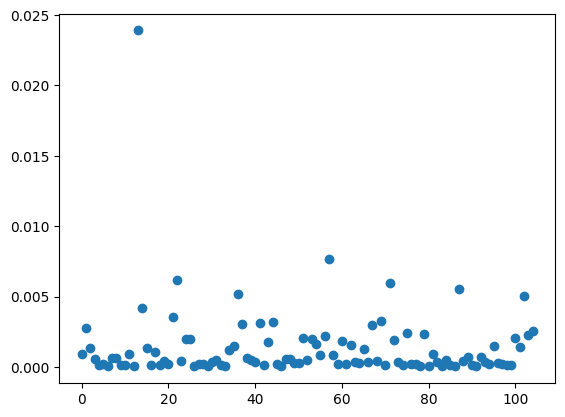

In [39]:
squared = np.diagonal(X_train_max @ X_train_max.T)
plt.scatter([i for i in range(squared.shape[0])], squared)
plt.show()

In [40]:
squared[noise]

array([0.00278182, 0.00055581, 0.0239079 , 0.00421011, 0.00015525,
       0.00353933, 0.00619151, 0.00197386, 0.00199653, 0.00019288,
       0.00121534, 0.00519767, 0.0030194 , 0.00049319, 0.00312053,
       0.00178234, 0.00317026, 0.00056707, 0.00028358, 0.00030508,
       0.00196443, 0.00165526, 0.00217234, 0.00763573, 0.00186201,
       0.00158186, 0.00295853, 0.00041507, 0.00325398, 0.00597337,
       0.00194301, 0.00031606, 0.00244398, 0.0023178 , 0.00555724,
       0.00043858, 0.00071714, 0.00069289, 0.00023408, 0.00203561,
       0.00142233, 0.00506149, 0.0022676 , 0.00256215])

In [41]:
clustering_kmeans = KMeans(n_clusters=2, random_state=RANDOM_STATE).fit(X_train_max)
clustering_kmeans.labels_

array([1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1], dtype=int32)

**Проверяем DBSCAN метрики на тесте**

In [42]:
def predict_dbscan(X_train, v, eps):
    distances = euclidean_distances([v], X_train[clustering_dbscan.core_sample_indices_])[0]
    
    min_dist_idx = np.argmin(distances)
    min_dist = distances[min_dist_idx]
    
    if min_dist <= eps:
        return clustering_dbscan.labels_[clustering_dbscan.core_sample_indices_[min_dist_idx]]
    else:
        return -1

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_dbscan(X_train_max, X_test[i - N], EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"DBSCAN - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

DBSCAN - Accuracy: 0.5265, Recall: 0.5000, Precision: 0.0237, F1 Score: 0.0453, ROC_AUC: 0.5136


**Проверяем Kmeans метрики на тесте**

In [43]:
def predict_kmeans(v, threshold=None):
    label = clustering_kmeans.predict([v])[0]
    
    if threshold is not None:
        dist = euclidean_distances([v], [clustering_kmeans.cluster_centers_[label]])[0][0]
        if dist > threshold:
            return -1
    
    return label

y_true = df_test['is_max'][N:]
y_pred = []
for i in range(N, df_test.shape[0]):
    prediction = predict_kmeans(X_test[i - N], threshold=EPS)
    y_pred.append(prediction != -1)

accuracy = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_pred)
print(f"Kmeans - Accuracy: {accuracy:.4f}, Recall: {recall:.4f}, Precision: {precision:.4f}, F1 Score: {f1:.4f}, ROC_AUC: {roc_auc:.4f}")

Kmeans - Accuracy: 0.8082, Recall: 0.1818, Precision: 0.0230, F1 Score: 0.0408, ROC_AUC: 0.5022
